# Normalización Batch y Layer: Estabilizando Redes Ultra-Profundas


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/03_normalizacion_batch_y_layer.ipynb)

## Objetivos


- Comprender el fenómeno del ***Internal Covariate Shift*** y por qué la inicialización de pesos no es suficiente para redes muy profundas.
- Analizar curvas de entrenamiento reales para entender que la normalización altera el panorama de optimización y requiere recalibrar hiperparámetros (el "engaño" de la normalización).
- Demostrar cómo la normalización actúa como una red de seguridad frente a inicializaciones subóptimas.
- Analizar el fallo catastrófico de *Batch Normalization* frente a tamaños de lote (*batch sizes*) pequeños e introducir ***Layer Normalization*** como la solución robusta.


## Prerrequisitos


- Entendimiento del *Forward Pass*, *Backpropagation* y el problema de la varianza.
- Haber completado: [Inicialización de Pesos y Redes Profundas](02_inicializacion_y_redes_profundas.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow versión: {tf.__version__}")

TensorFlow versión: 2.20.0


In [2]:
# ⚠️ CRITERIO DE INGENIERÍA: Verificación de Hardware
# Aunque este notebook puede ejecutarse en CPU, se acostumbra a verificar la disponibilidad de GPU.
# Entrenar redes profundas en CPU es un cuello de botella inaceptable en entornos de producción.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento será significativamente más lento.")

ADVERTENCIA: No se detectó GPU. El entrenamiento será significativamente más lento.


> **NOTA**: Cuando realmente "valga la pena" utilizar GPU, aviso (y muestro la diferencia).
> Por el momento, y utilizando el *tier free* de Colab... seguimos con CPU nomás.

## 1. Introducción Teórica: El Caos Interno


En el notebook anterior, logramos estabilizar una red utilizando la inicialización **He Normal**. Al inicio del entrenamiento (Época 0), la varianza fluía perfectamente.

Sin embargo, ¿qué ocurre en la Época 10 o en la Época 50?
Durante el entrenamiento, los pesos de la Capa 1 se actualizan. Esto cambia la distribución de las salidas de la Capa 1. La Capa 2 ahora recibe datos con una distribución diferente a la que tenía hace un momento, por lo que sus pesos deben re-adaptarse. Este efecto dominó se amplifica a medida que avanzamos hacia las capas más profundas.

A este fenómeno se le conoce como ***Internal Covariate Shift*** (Desplazamiento de Covariable Interno).

**Analogía de Ingeniería:** Supongamos que estamos construyendo una línea de ensamblaje de automóviles. La estación 1 pone el chasis, la estación 2 pone el motor. Si la estación 1 de repente decide entregar el chasis al revés, la estación 2 fallará y tendrá que reprogramar sus robots. Las capas de una red neuronal sufren este mismo problema: están intentando aprender sobre un objetivo en constante movimiento.

### La Solución: Forzar la Estabilidad Matemática


En 2015, se propuso una idea radical: **forzar matemáticamente** a que las activaciones de cada capa mantengan una media de 0 y una desviación estándar de 1, *en cada paso del entrenamiento*.

Para un lote (*batch*) de datos, **Batch Normalization** realiza la siguiente operación:
1. **Calcula la media del lote:** $\mu_B$
2. **Calcula la varianza del lote:** $\sigma_B^2$
3. **Normaliza:** $\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$ (donde $\epsilon$ evita la división por cero).

**El Toque Maestro:** Si forzamos a que la salida sea siempre una campana de Gauss perfecta, podríamos estar destruyendo información útil. Por lo tanto, se añaden dos parámetros **entrenables** ($\gamma$ para escalar y $\beta$ para desplazar):

$$ y_i = \gamma \hat{x}_i + \beta $$

La red ahora tiene el control: si necesita que la media sea 5 para resolver el problema, aprenderá a hacer $\beta = 5$. Pero lo hará de forma controlada.


## 2. Experimento 1: El "Engaño" de la Normalización


En ingeniería, es muy común añadir una técnica avanzada (como Batch Norm) a un modelo que ya funcionaba decentemente, y descubrir que el rendimiento **empeora**. Vamos a replicar este escenario exacto para aprender a diagnosticarlo.

Construimos una red de 10 capas, bien inicializada (`he_normal`), y usamos un *Learning Rate* alto (`0.05`). Comparamos el modelo sin normalizar contra versiones con Batch y Layer Normalization.

Usamos el *dataset* para clasificar imágenes de ropa (Fashion MNIST). Los modelos a comparar serían:
- **Modelo A:** Estándar (He Normal + ReLU).
- **Modelo B:** Estándar + Batch Normalization.
- **Modelo C:** Estándar + Layer Normalization.

Entrenando Modelo A (Sin Norm)...
Entrenando Modelo B (Batch Norm)...
Entrenando Modelo C (Layer Norm)...
Entrenamientos finalizados.


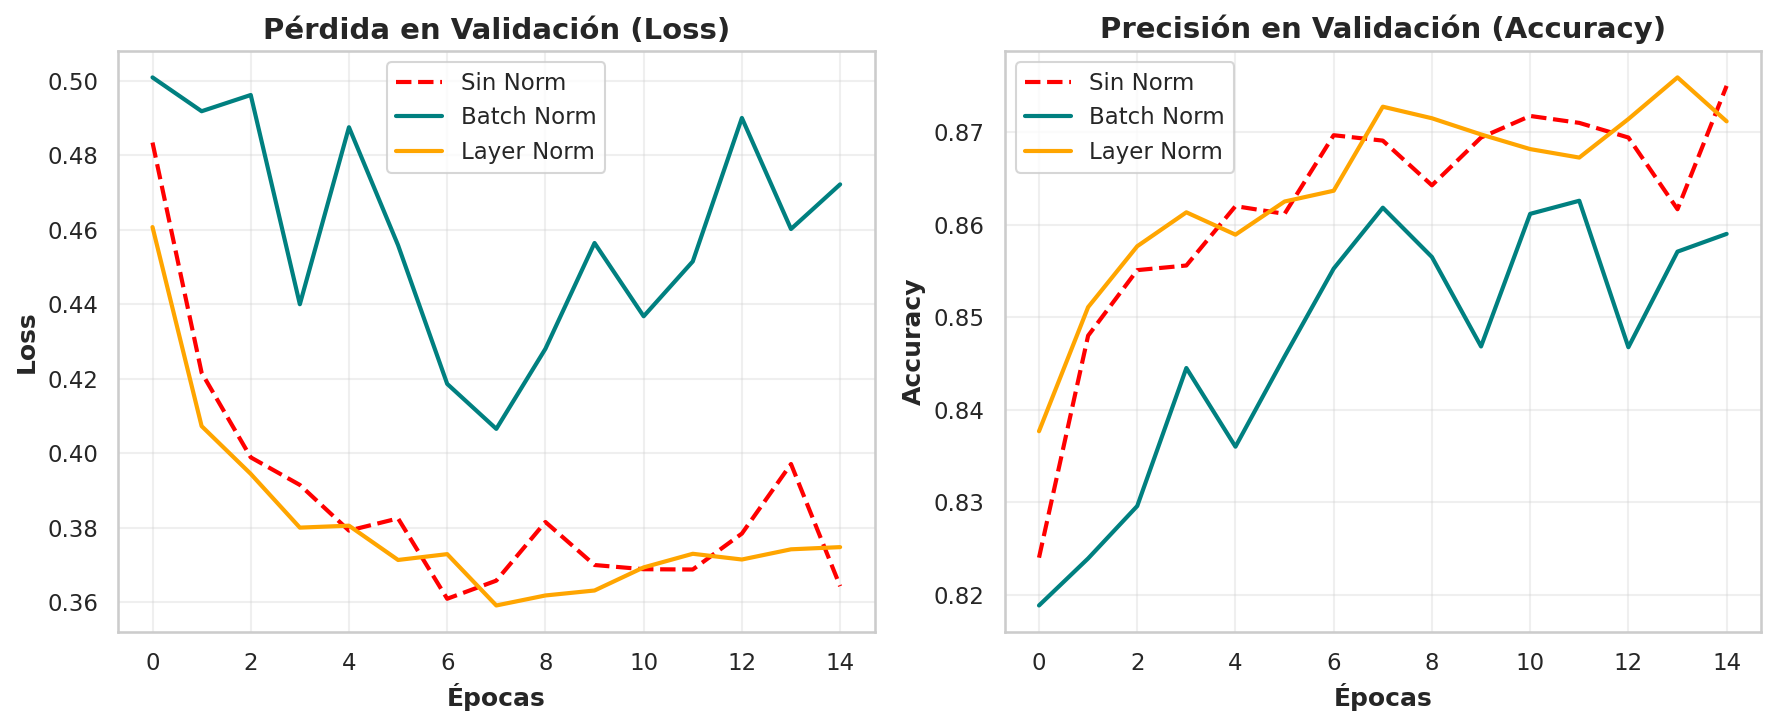

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, LayerNormalization, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.optimizers import SGD

# 1. Carga de datos
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Función constructora flexible
def construir_modelo(tipo_norm=None, inicializador='he_normal', capas=10):
    modelo = Sequential()
    modelo.add(Input(shape=(28, 28)))
    modelo.add(Flatten())

    for _ in range(capas):
        modelo.add(Dense(100, kernel_initializer=inicializador))

        # Inyección de la Normalización
        if tipo_norm == 'batch':
            modelo.add(BatchNormalization())
        elif tipo_norm == 'layer':
            modelo.add(LayerNormalization(axis=-1))

        modelo.add(tf.keras.layers.Activation('relu'))

    modelo.add(Dense(10, activation='softmax'))
    return modelo

# 3. Entrenamiento (Escenario: Buena inicialización, LR alto)
print("Entrenando Modelo A (Sin Norm)...")
modelo_a = construir_modelo(tipo_norm=None)
modelo_a.compile(optimizer=SGD(learning_rate=0.05), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_a = modelo_a.fit(X_train, y_train, epochs=15, validation_split=0.2, batch_size=64, verbose=0)

print("Entrenando Modelo B (Batch Norm)...")
modelo_b = construir_modelo(tipo_norm='batch')
modelo_b.compile(optimizer=SGD(learning_rate=0.05), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_b = modelo_b.fit(X_train, y_train, epochs=15, validation_split=0.2, batch_size=64, verbose=0)

print("Entrenando Modelo C (Layer Norm)...")
modelo_c = construir_modelo(tipo_norm='layer')
modelo_c.compile(optimizer=SGD(learning_rate=0.05), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_c = modelo_c.fit(X_train, y_train, epochs=15, validation_split=0.2, batch_size=64, verbose=0)
print("Entrenamientos finalizados.")

# 4. Visualización
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_a.history['val_loss'], label='Sin Norm', color='red', linestyle='--', linewidth=2)
plt.plot(hist_b.history['val_loss'], label='Batch Norm', color='teal', linewidth=2)
plt.plot(hist_c.history['val_loss'], label='Layer Norm', color='orange', linewidth=2)
plt.title("Pérdida en Validación (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(hist_a.history['val_accuracy'], label='Sin Norm', color='red', linestyle='--', linewidth=2)
plt.plot(hist_b.history['val_accuracy'], label='Batch Norm', color='teal', linewidth=2)
plt.plot(hist_c.history['val_accuracy'], label='Layer Norm', color='orange', linewidth=2)
plt.title("Precisión en Validación (Accuracy)")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de Resultados (la práctica "desafía" la teoría)


Observar las curvas detenidamente. La teoría ingenua diría que la normalización siempre gana, pero los resultados empíricos muestran otra cosa:

- **El Modelo A (Sin Norm)** (línea roja punteada) logra una convergencia excelente, estable y con la menor pérdida. ¿Por qué? Porque hicimos las cosas bien desde el principio: usamos inicialización `he_normal` con `ReLU`, lo cual es suficiente para mantener estable esta arquitectura.
- **El Modelo B (Batch Norm)** (línea verde) se vuelve **completamente errático**. Su pérdida rebota violentamente y su precisión es inferior. ¿Por qué falló? Porque Batch Norm altera drásticamente la topología del espacio de optimización. Al usar un *Learning Rate* alto (0.05) en una red que ya estaba bien inicializada, Batch Norm empuja los gradientes hacia un régimen caótico.
- **El Modelo C (Layer Norm)** (línea naranja) logra seguir el ritmo del modelo base, pero hacia la época 14 comienza a mostrar signos de inestabilidad (el *Loss* sube).

> **⚠️ LECCIÓN DE INGENIERÍA:** La normalización no es "magia" que se "enchufa" para mejorar métricas. Es una herramienta que **acelera drásticamente la dinámica de la red**. Si la inyectamos sin re-calibrar nuestros hiperparámetros (específicamente, reduciendo el *learning rate*), la red pasará de largo el mínimo óptimo y se volverá inestable. En Deep Learning, cambiar un componente altera todo el ecosistema.

## 3. Experimento 2: El Poder Real (La Red de Seguridad)

Si la normalización nos hizo sobreajustar en el caso anterior, ¿para qué la usamos?
La usamos porque en el mundo real no siempre tenemos la inicialización perfecta, o necesitamos arquitecturas de 50 o 100 capas donde incluso `he_normal` empieza a fallar.

Vamos a simular un entorno más hostil: construimos una red de **15 capas** y cometemos el error de principiante de usar la inicialización por defecto de Keras (`glorot_uniform`) junto con `ReLU`.


> **NOTA**: Sabemos por el notebook anterior que esto destruye la varianza. Podríamos ver si la normalización puede "rescatar" a una red matemáticamente muerta. (*Para generar este escenario... experimentar con mayor profundidad y re-ejecutar la celda de abajo. `capas=35` por ejemplo*).

Entrenando Modelo A (Sin Norm | Glorot + ReLU)...
Entrenando Modelo B (Batch Norm | Glorot + ReLU)...
Entrenamientos finalizados.


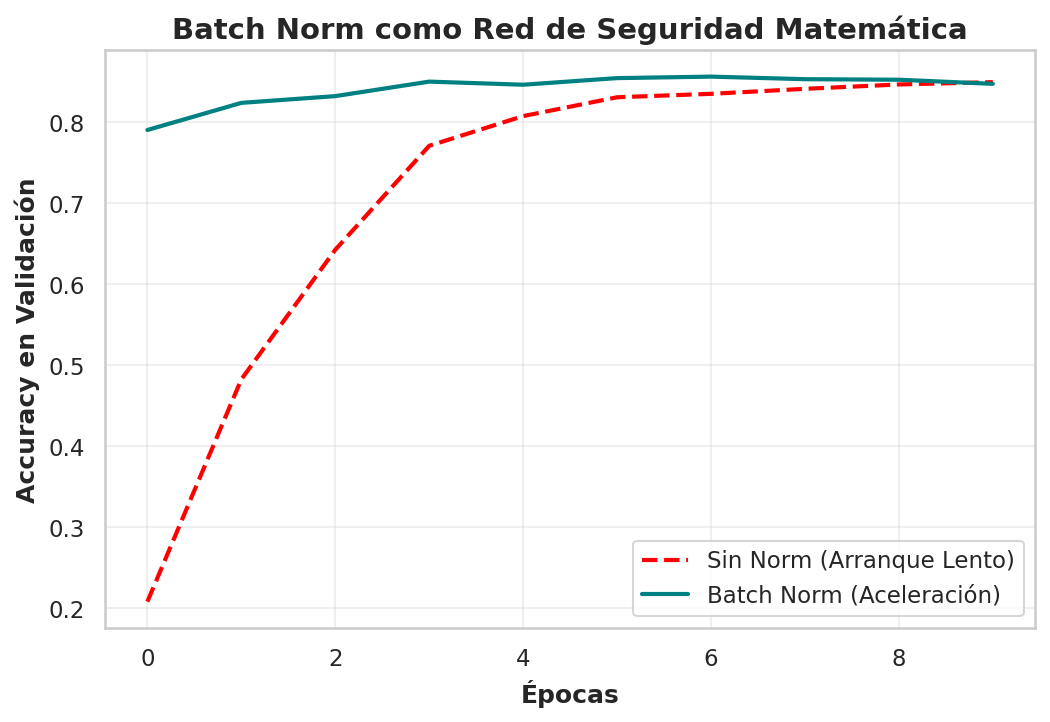

In [13]:
# Entrenamiento (Escenario: Mala inicialización, Red más profunda)
print("Entrenando Modelo A (Sin Norm | Glorot + ReLU)...")
# glorot_uniform es el default en Keras si no se especifica
modelo_malo_a = construir_modelo(tipo_norm=None, inicializador='glorot_uniform', capas=15)
modelo_malo_a.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_malo_a = modelo_malo_a.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=64, verbose=0)

print("Entrenando Modelo B (Batch Norm | Glorot + ReLU)...")
modelo_malo_b = construir_modelo(tipo_norm='batch', inicializador='glorot_uniform', capas=15)
modelo_malo_b.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_malo_b = modelo_malo_b.fit(X_train, y_train, epochs=10, validation_split=0.2, batch_size=64, verbose=0)
print("Entrenamientos finalizados.")

# Visualización
plt.figure(figsize=(8, 5))
plt.plot(hist_malo_a.history['val_accuracy'], label='Sin Norm (Arranque Lento)', color='red', linestyle='--', linewidth=2)
plt.plot(hist_malo_b.history['val_accuracy'], label='Batch Norm (Aceleración)', color='teal', linewidth=2)

plt.title("Batch Norm como Red de Seguridad Matemática", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Accuracy en Validación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Análisis: (rescate y/o aceleración)

Aquí es donde brilla verdaderamente la normalización en entornos subóptimos. Observar la diferencia abismal en la velocidad de aprendizaje:

- La red **Sin Norm** (línea roja) sufre una "agonía" inicial. Arranca con apenas un 35% de precisión y le toma casi 5 épocas alcanzar un rendimiento decente. La mala inicialización (Glorot + ReLU) atenuó severamente los gradientes en las primeras capas, haciendo que la red aprenda a paso de tortuga.
- La red con **Batch Norm** (línea verde) actúa como un cohete. Ignora por completo la mala inicialización y arranca rozando el **80% de precisión desde la primera época**.

Al forzar matemáticamente la varianza a 1 en cada capa, Batch Norm resucita la fuerza de los gradientes en tiempo real. No solo actúa como una red de seguridad contra malas decisiones de arquitectura, sino que **ahorra valioso tiempo de cómputo** al acelerar masivamente las primeras fases del entrenamiento.

> **NOTA**: comprobar qué pasa con el caso extremo de 35 capas.

## 4. El Talón de Aquiles: Sensibilidad al Tamaño del Lote



Si Batch Normalization es tan bueno, ¿por qué no lo usamos en absolutamente todos los modelos?

El problema reside en su propio nombre: depende del **Batch** (Lote).
Para calcular una media ($\mu$) y una varianza ($\sigma^2$) representativas, necesitamos una muestra estadística decente.
- Si nuestro `batch_size = 128`, la media y la varianza calculadas serán muy precisas.
- Si estamos procesando imágenes médicas 3D de alta resolución, quizás nuestra memoria RAM/VRAM solo soporte un `batch_size = 2` o `4`.

> **⚠️ PELIGRO:** Calcular la varianza de 2 elementos genera un ruido estadístico masivo. En lugar de estabilizar la red, Batch Normalization inyectará caos en los gradientes, destruyendo el entrenamiento.

Vamos a demostrar empíricamente este "Talón de Aquiles" de Batch Norm. Entrenamos dos redes profundas de 5 capas, pero esta vez simulamos una restricción extrema de memoria usando un **`batch_size = 2`**.

*(Nota: Usamos un subconjunto de datos para no demorar la ejecución).*

Entrenando Batch Norm (Batch Size = 2)...
Entrenando Layer Norm (Batch Size = 2)...
Entrenamientos finalizados.


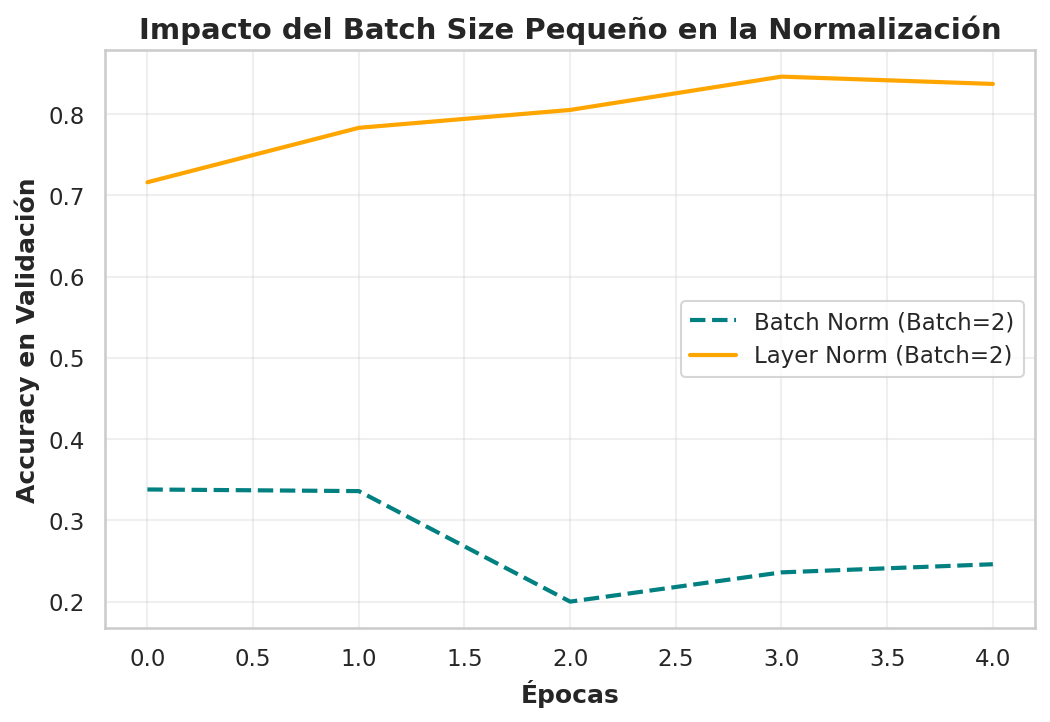

In [14]:
# Extraemos un subconjunto de 5.000 imágenes para iterar rápido
X_train_subset = X_train[:5000]
y_train_subset = y_train[:5000]

print("Entrenando Batch Norm (Batch Size = 2)...")
modelo_bn_small = construir_modelo(tipo_norm='batch', inicializador='he_normal', capas=5)
modelo_bn_small.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# 5 épocas son suficientes para ver el comportamiento
hist_bn_small = modelo_bn_small.fit(X_train_subset, y_train_subset, epochs=5, validation_split=0.2, batch_size=2, verbose=0)

print("Entrenando Layer Norm (Batch Size = 2)...")
modelo_ln_small = construir_modelo(tipo_norm='layer', inicializador='he_normal', capas=5)
modelo_ln_small.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_ln_small = modelo_ln_small.fit(X_train_subset, y_train_subset, epochs=5, validation_split=0.2, batch_size=2, verbose=0)
print("Entrenamientos finalizados.")

# Visualización del desastre
plt.figure(figsize=(8, 5))
plt.plot(hist_bn_small.history['val_accuracy'], label='Batch Norm (Batch=2)', color='teal', linestyle='--', linewidth=2)
plt.plot(hist_ln_small.history['val_accuracy'], label='Layer Norm (Batch=2)', color='orange', linewidth=2)

plt.title("Impacto del Batch Size Pequeño en la Normalización", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("Accuracy en Validación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Análisis:

La gráfica confirma nuestra hipótesis matemática con una precisión asombrosa:

- **Batch Normalization colapsa (Línea verde punteada).** Al intentar calcular estadísticos con solo 2 imágenes, inyecta puro ruido. La red se vuelve incapaz de aprender, estancándose en un rendimiento inservible.
- **Layer Normalization sobrevive y triunfa (Línea naranja sólida).** En lugar de mirar a los "compañeros" del lote, Layer Norm mira hacia adentro: calcula la media y varianza utilizando todas las neuronas de esa capa para una *única* muestra de datos. Le es completamente indiferente que el lote sea de 2 o de 1.000.

### Tabla de Decisión: Alternativas de Normalización



Para solucionar esto, la ingeniería de IA desarrolló alternativas que no dependen del tamaño del lote.

| Técnica | ¿Qué normaliza? | Dependencia del Batch Size | Uso Principal |
| :--- | :--- | :--- | :--- |
| **Batch Normalization** | Una característica (feature) a través de todo el lote. | **Alta.** Falla si Batch es chico. | CNNs clásicas (ResNet, EfficientNet). |
| **Layer Normalization** | Todas las características de una **sola instancia** (ej. una imagen o un texto). | **Nula.** Funciona con Batch = 1. | **Transformers (LLMs)**, RNNs, y cuando la VRAM es limitada. |
| **Instance Normalization** | Una característica en una sola instancia (espacialmente). | Nula. | Transferencia de Estilo (GANs). |
| **Group Normalization** | Grupos de características en una sola instancia. | Nula. | Detección de objetos con imágenes gigantes. |



### ¿Cuándo usar cuál? (Criterio de Ingeniería)



1. **¿Estamos trabajando con Visión por Computadora (Imágenes) y tenemos suficiente VRAM para lotes de 32 o más?** Usar `BatchNormalization`. Sigue siendo el rey empírico en CNNs.
2. **¿Estamos trabajando con Texto (NLP), Series Temporales, o la VRAM solo permite lotes de 2 o 4 imágenes?** Usar `LayerNormalization`.
3. **¿Estamos haciendo Fine-Tuning de un modelo pre-entrenado?** Respetar la normalización que usó el autor original. Cambiarla invalidará los pesos pre-entrenados. (*recordar esto para el final del capítulo...*)



## Conexiones y Próximos Pasos


Resolvimos la estabilidad matemática de la red (o al menos tenemos una idea). Con una buena inicialización y normalización, la señal fluye perfectamente desde la entrada hasta la salida, y los gradientes fluyen de regreso sin desvanecerse ni explotar.

Sin embargo, hasta ahora confiamos ciegamente en el optimizador `SGD` (Descenso del Gradiente Estocástico). En problemas complejos, SGD es demasiado lento y propenso a quedarse atascado en valles locales.

- ➡️ **Siguiente:** En el notebook [Optimizadores y Regularización](04_optimizadores_y_regularizacion.ipynb), abandonamos el SGD básico y entendemos la física detrás del **Momentum**, RMSProp y el estándar absoluto de la industria: **Adam**. Además, aprendemos a combatir el sobreajuste (*Overfitting*) usando Dropout.

## Referencias


### Artículos Fundacionales

1. **Ioffe, S., & Szegedy, C. (2015)**. *Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift*. International Conference on Machine Learning (ICML).  
   [[arXiv]](https://arxiv.org/abs/1502.03167)  
   (Paper original que introdujo Batch Normalization).

2. **Ba, J. L., Kiros, J. R., & Hinton, G. E. (2016)**. *Layer Normalization*. arXiv preprint.  
   [[arXiv]](https://arxiv.org/abs/1607.06450)  
   (Paper que introdujo Layer Normalization, clave para Transformers).

3. **Wu, Y., & He, K. (2018)**. *Group Normalization*. European Conference on Computer Vision (ECCV).  
   [[arXiv]](https://arxiv.org/abs/1803.08494)  
   (Excelente explicación de las limitaciones de BatchNorm con lotes pequeños).

### Lecturas Complementarias

- **Goodfellow, I., Bengio, Y., & Courville, A. (2016)**. *Deep Learning* (Capítulo 8). MIT Press. Disponible gratis en [deeplearningbook.org](https://www.deeplearningbook.org/).
- **Santurkar, S., Tsipras, D., Ilyas, A., & Madry, A. (2018)**. *How Does Batch Normalization Help Optimization?* NeurIPS.  
  (Análisis teórico profundo sobre por qué BatchNorm funciona tan bien).
- Documentación oficial de Keras:  
  [BatchNormalization](https://keras.io/api/layers/normalization_layers/batch_normalization/)  
  [LayerNormalization](https://keras.io/api/layers/normalization_layers/layer_normalization/)

### Recursos Visuales
- 3Blue1Brown – Serie Neural Networks (episodios sobre normalización).

---


## Entorno de Ejecución


In [15]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
keras,3.13.2
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
